<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/ml5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_excel('http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls')
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


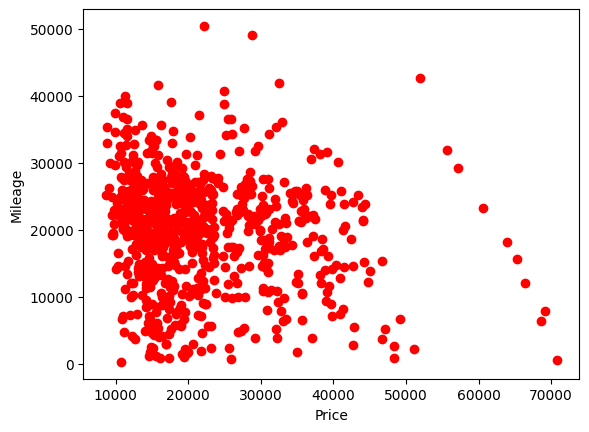

In [2]:
plt.scatter(df['Price'],df['Mileage'],color='red')
plt.xlabel('Price')
plt.ylabel('Mileage')
plt.show()

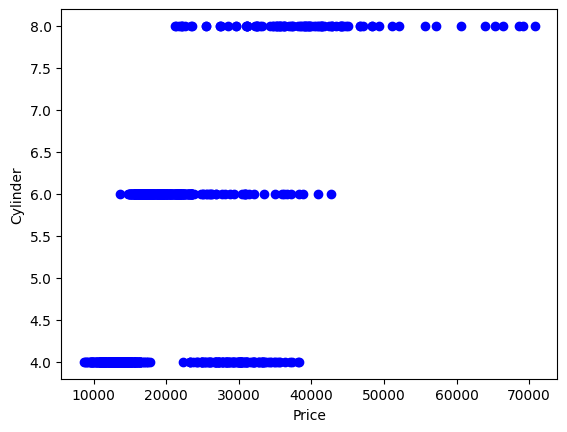

In [3]:
plt.scatter(df['Price'],df['Cylinder'],color='blue')
plt.xlabel('Price')
plt.ylabel('Cylinder')
plt.show()

In [12]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X=df[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']]
y=df['Price']
X[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']]=scale.fit_transform(X[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']])
print(X)
X=sm.add_constant(X)
print(X)
est=sm.OLS(y,X).fit()
est.summary()

      Mileage  Cylinder     Doors   Cruise     Sound   Leather
0   -1.417485   0.52741  0.556279  0.57352  0.687406  0.617611
1   -1.305902   0.52741  0.556279  0.57352  0.687406 -1.619142
2   -0.810128   0.52741  0.556279  0.57352  0.687406 -1.619142
3   -0.426058   0.52741  0.556279  0.57352 -1.454744 -1.619142
4    0.000008   0.52741  0.556279  0.57352 -1.454744  0.617611
..        ...       ...       ...      ...       ...       ...
799 -0.439853   0.52741  0.556279  0.57352 -1.454744 -1.619142
800 -0.089966   0.52741  0.556279  0.57352  0.687406 -1.619142
801  0.079605   0.52741  0.556279  0.57352  0.687406 -1.619142
802  0.750446   0.52741  0.556279  0.57352  0.687406 -1.619142
803  1.932565   0.52741  0.556279  0.57352 -1.454744 -1.619142

[804 rows x 6 columns]
     const   Mileage  Cylinder     Doors   Cruise     Sound   Leather
0      1.0 -1.417485   0.52741  0.556279  0.57352  0.687406  0.617611
1      1.0 -1.305902   0.52741  0.556279  0.57352  0.687406 -1.619142
2      1.0

/tmp/ipykernel_8837/1500255460.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']]=scale.fit_transform(X[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']])


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     106.8
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.23e-98
Time:                        07:46:41   Log-Likelihood:                -8298.9
No. Observations:                 804   AIC:                         1.661e+04
Df Residuals:                     797   BIC:                         1.664e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.134e+04    260.523     81.924      0.000    2.08e+04    2.19e+04
Mileage    -1396.7431    260.969     -5.352      0.000   -1909.010    -884.476
Cylinder    4437.5107    281.470     15.765      0.000    3885.000    4990.022
Doors      -1243.3623    261.922     -4.747      0.000   -1757.501    -729.223
Cruise      2678.0936    281.150      9.525      0.000    2126.211    3229.976
Sound       -945.0322    266.423     -3.547      0.000   -1468.006    -422.058
Leather     1487.4879    266.956      5.572      0.000     963.468    2011.507
==============================================================================
Omnibus:                      145.941   Durbin-Watson:                   0.304
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.863
Skew:                           1.098   Prob(JB):                     6.15e-57
Kurtosis:                       4.703   Cond. No.                         1.52
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

X=df[['Mileage','Cylinder','Doors','Cruise','Sound','Leather']]
y=df['Price']

poly=PolynomialFeatures(degree=2,include_bias=False)

X=poly.fit_transform(X)
X_poly=pd.DataFrame(X,columns=poly.get_feature_names_out(['Mileage','Cylinder','Doors','Cruise','Sound','Leather']))
print(X_poly)

X_poly=X_poly.drop(columns=['Mileage','Mileage^2','Mileage Doors','Mileage Cruise','Mileage Sound','Mileage Leather','Cylinder Cruise','Doors Cruise','Cruise Leather'])

est=sm.OLS(y,X_poly).fit()
est.summary()



     Mileage  Cylinder  Doors  Cruise  Sound  Leather     Mileage^2  \
0     8221.0       6.0    4.0     1.0    1.0      1.0  6.758484e+07   
1     9135.0       6.0    4.0     1.0    1.0      0.0  8.344822e+07   
2    13196.0       6.0    4.0     1.0    1.0      0.0  1.741344e+08   
3    16342.0       6.0    4.0     1.0    0.0      0.0  2.670610e+08   
4    19832.0       6.0    4.0     1.0    0.0      1.0  3.933082e+08   
..       ...       ...    ...     ...    ...      ...           ...   
799  16229.0       6.0    4.0     1.0    0.0      0.0  2.633804e+08   
800  19095.0       6.0    4.0     1.0    1.0      0.0  3.646190e+08   
801  20484.0       6.0    4.0     1.0    1.0      0.0  4.195943e+08   
802  25979.0       6.0    4.0     1.0    1.0      0.0  6.749084e+08   
803  35662.0       6.0    4.0     1.0    0.0      0.0  1.271778e+09   

     Mileage Cylinder  Mileage Doors  Mileage Cruise  ...  Doors^2  \
0             49326.0        32884.0          8221.0  ...     16.0   
1      

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     85.77
Date:                Sun, 10 May 2026   Prob (F-statistic):          8.96e-148
Time:                        08:10:21   Log-Likelihood:                -8164.3
No. Observations:                 804   AIC:                         1.636e+04
Df Residuals:                     789   BIC:                         1.643e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Cylinder         -2.098e+04   1972.779    -10.633      0.000   -2.48e+04   -1.71e+04
Doors             5.383e+04   4240.273     12.696      0.000    4.55e+04    6.22e+04
Cruise            5341.0939    582.548      9.169      0.000    4197.567    6484.621
Sound            -5137.4123   1476.264     -3.480      0.001   -8035.282   -2239.543
Leather          -3883.9129   1693.607     -2.293      0.022   -7208.422    -559.404
Mileage Cylinder    -0.0345      0.005     -6.987      0.000      -0.044      -0.025
Cylinder^2        2081.4333    159.694     13.034      0.000    1767.957    2394.909
Cylinder Doors    -385.6773    179.721     -2.146      0.032    -738.465     -32.890
Cylinder Sound    2326.2161    381.749      6.094      0.000    1576.853    3075.580
Cylinder Leather   976.7184    535.368      1.824      0.068     -74.196    2027.633
Doors^2          -8999.6696    825.883    -10.897      0.000   -1.06e+04   -7378.482
Doors Sound        773.7518    596.678      1.297      0.195    -397.513    1945.017
Doors Leather     1580.9794    636.371      2.484      0.013     331.798    2830.161
Cruise^2          5341.0939    582.548      9.169      0.000    4197.567    6484.621
Cruise Sound     -4823.3328   1326.902     -3.635      0.000   -7428.009   -2218.656
Sound^2          -5137.4123   1476.264     -3.480      0.001   -8035.282   -2239.543
Sound Leather    -2709.9711   1062.310     -2.551      0.011   -4795.260    -624.682
Leather^2        -3883.9129   1693.607     -2.293      0.022   -7208.422    -559.404
==============================================================================
Omnibus:                       77.012   Durbin-Watson:                   0.491
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.829
Skew:                           0.648   Prob(JB):                     6.43e-29
Kurtosis:                       4.482   Cond. No.                     4.99e+21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.37e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""